In [1]:
# 05c_model_evaluation.ipynb

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data and model
test_df = pd.read_csv("../data/processed/test_enhanced_processed.csv")
X_test = test_df.drop(columns=['selling_price'])
y_test = test_df['selling_price']

model = joblib.load('../models/best_model_enhanced.pkl')

In [3]:
# Predict
y_pred = model.predict(X_test)

# Basic metrics
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_test.mean())**2)

print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)
print(f"MAE:  ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R²:   {r2:.4f}")


FINAL MODEL PERFORMANCE
MAE:  ₹97,149
RMSE: ₹201,769
R²:   0.9459


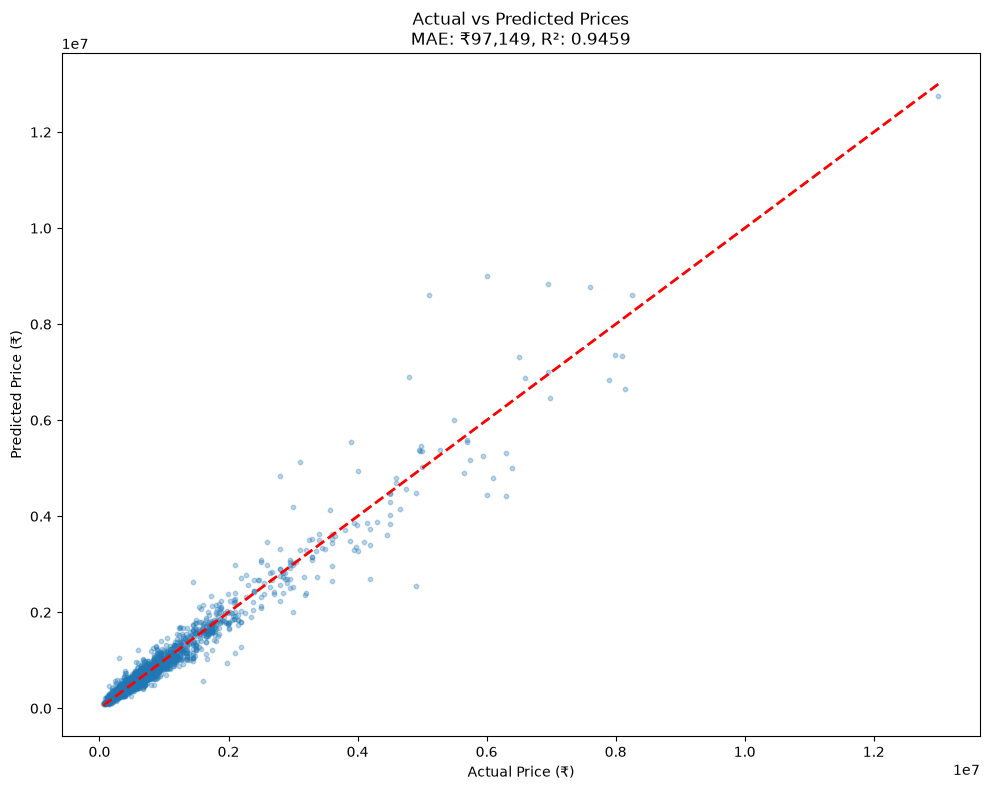

In [5]:
# 1. Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title(f'Actual vs Predicted Prices\nMAE: ₹{mae:,.0f}, R²: {r2:.4f}')
plt.tight_layout()
# plt.savefig('../reports/figures/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()


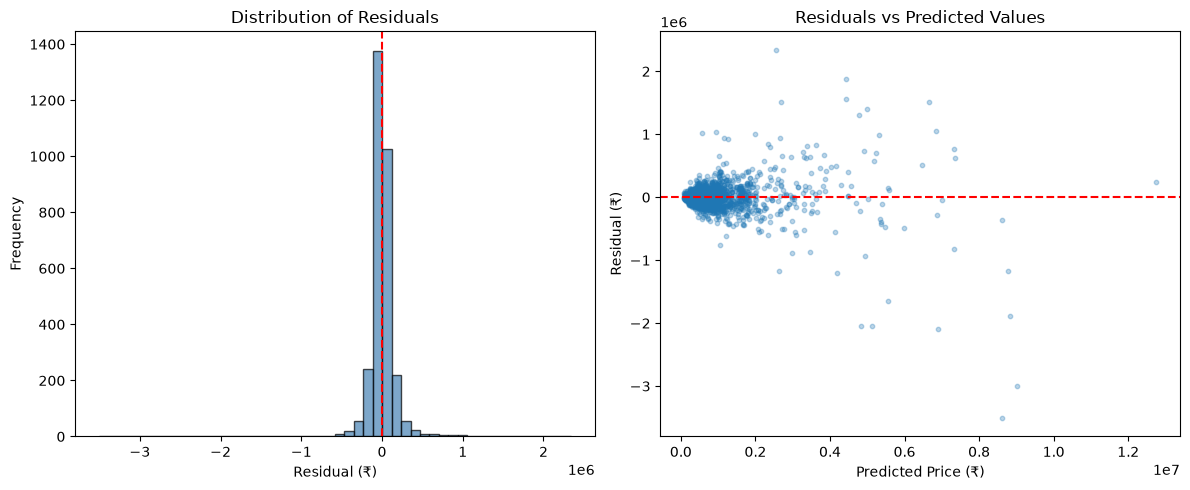

In [7]:
# 2. Residuals Distribution
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Residual (₹)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.axvline(x=0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price (₹)')
plt.ylabel('Residual (₹)')
plt.title('Residuals vs Predicted Values')

plt.tight_layout()
# plt.savefig('../reports/figures/residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

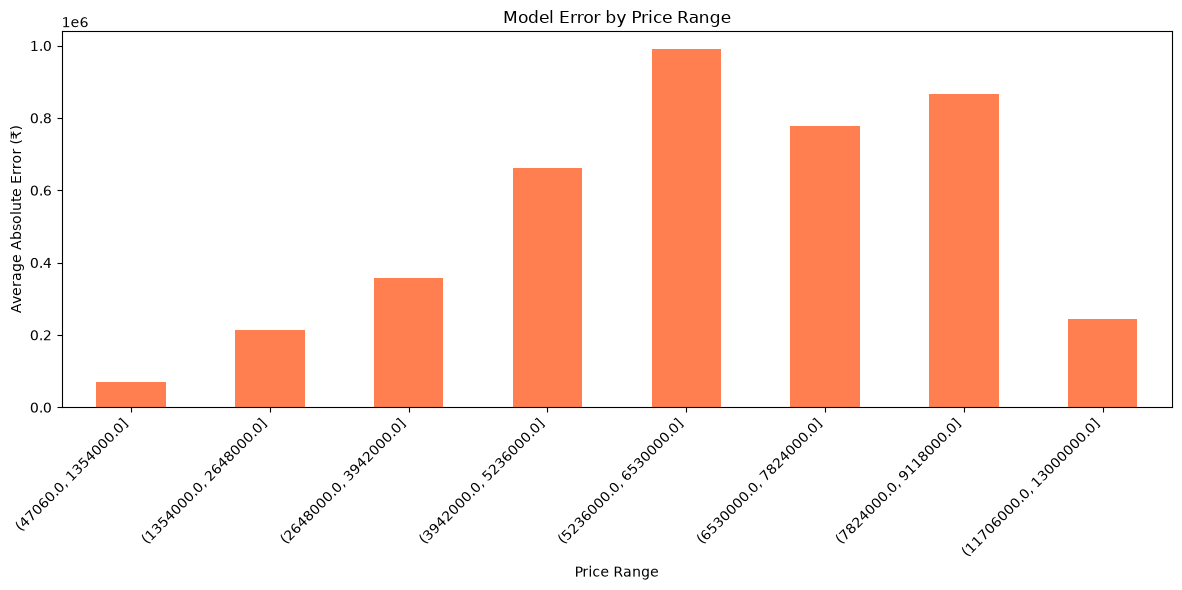

In [8]:
# 3. Error by Price Range
price_bins = pd.cut(y_test, bins=10)
error_by_price = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'error': np.abs(y_test - y_pred),
    'price_bin': price_bins
})

# Calculate average error by price range
avg_error_by_price = error_by_price.groupby('price_bin')['error'].mean()

plt.figure(figsize=(12, 6))
avg_error_by_price.plot(kind='bar', color='coral')
plt.xlabel('Price Range')
plt.ylabel('Average Absolute Error (₹)')
plt.title('Model Error by Price Range')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../reports/figures/error_by_price_range.png', dpi=300, bbox_inches='tight')
plt.show()

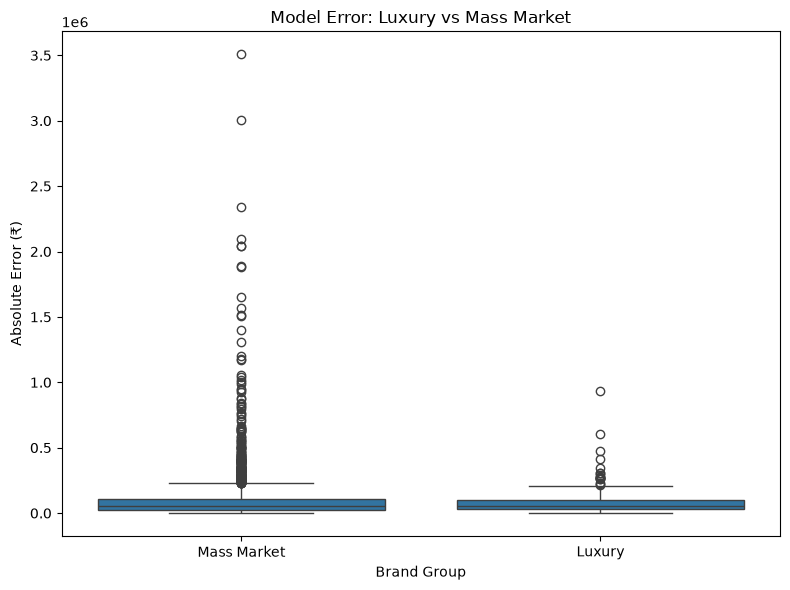

In [9]:
# 4. Error by Luxury vs Mass Market
# We need to load original data with brand_group
original_df = pd.read_csv("../data/processed/cardekho_enhanced.csv")
test_indices = y_test.index

# Get brand_group for test set
test_brand_group = original_df.loc[test_indices, 'brand_group']

error_by_brand_group = pd.DataFrame({
    'brand_group': test_brand_group,
    'error': np.abs(y_test - y_pred)
})

plt.figure(figsize=(8, 6))
sns.boxplot(data=error_by_brand_group, x='brand_group', y='error')
plt.xlabel('Brand Group')
plt.ylabel('Absolute Error (₹)')
plt.title('Model Error: Luxury vs Mass Market')
plt.tight_layout()
# plt.savefig('../reports/figures/error_by_brand_group.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# 5. Top 10 Worst Predictions
error_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'error': np.abs(y_test - y_pred),
    'error_pct': np.abs((y_test - y_pred) / y_test) * 100
}).sort_values('error', ascending=False)

print("\n" + "="*60)
print("TOP 10 WORST PREDICTIONS")
print("="*60)
print(error_df.head(10).to_string(index=False))


TOP 10 WORST PREDICTIONS
 actual  predicted      error  error_pct
5100000 8608032.00 3508032.00  68.784941
6000000 9005484.00 3005484.00  50.091400
4900000 2557377.25 2342622.75  47.808628
4800000 6898483.00 2098483.00  43.718396
2790000 4834549.50 2044549.50  73.281344
3100000 5138800.00 2038800.00  65.767742
6950000 8835729.00 1885729.00  27.132791
6300000 4420160.00 1879840.00  29.838730
3900000 5550371.50 1650371.50  42.317218
6000000 4435599.50 1564400.50  26.073342


In [11]:
# 6. Summary Statistics by Price Range
print("\n" + "="*60)
print("ERROR BY PRICE RANGE")
print("="*60)

price_ranges = pd.cut(y_test, bins=[0, 500000, 1000000, 2000000, 5000000, 10000000, 50000000])
summary_by_price = error_by_price.groupby('price_bin').agg({
    'actual': ['count', 'mean'],
    'error': ['mean', 'std']
}).round(0)

print(summary_by_price)


ERROR BY PRICE RANGE
                         actual                 error          
                          count        mean      mean       std
price_bin                                                      
(47060.0, 1354000.0]       2749    559011.0   68699.0   65725.0
(1354000.0, 2648000.0]      219   1793374.0  213336.0  198280.0
(2648000.0, 3942000.0]       59   3121339.0  357320.0  453342.0
(3942000.0, 5236000.0]       31   4489323.0  662180.0  757945.0
(5236000.0, 6530000.0]       14   5937429.0  990071.0  798211.0
(6530000.0, 7824000.0]        5   7014000.0  778977.0  748064.0
(7824000.0, 9118000.0]        5   8077000.0  865400.0  437232.0
(11706000.0, 13000000.0]      1  13000000.0  245119.0       NaN


In [17]:
import joblib
from sklearn.pipeline import Pipeline

# Load the preprocessor you saved earlier
preprocessor = joblib.load('../models/preprocessor_enhanced.pkl')

# Load your trained model
best_model = joblib.load('../models/best_model_enhanced.pkl')

# Create a complete pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)  # Your XGBoost model
])

# Save it
joblib.dump(full_pipeline, '../models/full_pipeline.pkl')

['../models/full_pipeline.pkl']